In [1]:
import numpy as np

In [2]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_initial_circuit2, concatenate_circuits_with_separate_measurements, add_cnots_and_measurements_to_circuit
from quantum_functions import add_crx_gates_and_measurements_to_circuit, get_probability_distribution, calculate_kl_divergence
from quantum_functions import score_circuit_kl_divergences, plot_measurement_histograms, create_cnot_pairs_from_locations, optimize_crx_angles
from quantum_functions import _process_target_state_input
from quantum_functions import find_best_cnot_sequence_brute_force, find_best_cnot_sequence_multi_epoch
from quantum_functions import vector_normalize_dictionary_values, find_best_cnot_sequence_iterative_n_wise

In [3]:
# 1. Define initial circuits for concatenation Dictionaries
state_probs_bell = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)} # 2-qubit state
circ_bell = create_initial_circuit2(state_probs_bell)

state_probs_ghz_ish = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)} # 2-qubit state
circ_ghz_ish = create_initial_circuit2(state_probs_ghz_ish)

# Define the target state vectors
state_probs_target1_amplitudes = {'01': 1/np.sqrt(2), '10': 1/np.sqrt(2)}
state_probs_target2_amplitudes = {'00': 1/np.sqrt(2), '11': 1/np.sqrt(2)}


In [4]:
# --- Demonstrate Brute-Force Search ---
print("\n" + "="*40)
print("--- Running Brute-Force Search ---")
print("="*40)
# WARNING: max_cnot_depth grows exponentially! Keep it small (e.g., 1, 2, or 3)
max_brute_force_depth = 10 # Testing up to 2 CNOTs for demonstration

best_cnot_sequence_brute_force, min_kl_brute_force = find_best_cnot_sequence_brute_force(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    max_cnot_depth=max_brute_force_depth,
    nshots=1000
)

print("\n" + "="*40)
if best_cnot_sequence_brute_force:
    print(f"Brute-Force Search Optimal CNOT sequence (Depth {max_brute_force_depth}) found:")
    for cnot in best_cnot_sequence_brute_force:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_brute_force:.6f}")

    # Construct and draw the final best circuit from brute-force search
    ng_circ1_for_brute_force = circ_bell.num_qubits
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, ng_circ1_for_brute_force, best_cnot_sequence_brute_force
    )
    print("\n--- Final Optimized Circuit (Brute-Force) ---")
    print(final_best_circuit_brute_force.draw('text'))
else:
    print("Brute-Force Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_brute_force:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_brute_force = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_brute_force = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_brute_force, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_brute_force.draw('text'))
print("="*40 + "\n")


--- Running Brute-Force Search ---

--- Starting Brute-Force CNOT Sequence Optimization (Total Qubits: 4, Max Depth: 10) ---
Number of qubits in chunk 1: 2
Number of qubits in chunk 2: 2

Baseline (No CNOTs) KL Sum: 40.060815
Initial best KL sum: 40.060815 (from baseline)

 Number of possible single cnots 8

--- Testing combinations with 1 CNOTs ---
  --> New best sequence found: [(0, 2)] with KL Sum: 29.633864
  --> New best sequence found: [(2, 0)] with KL Sum: 28.874527

--- Testing combinations with 2 CNOTs ---
  --> New best sequence found: [(0, 2), (2, 0)] with KL Sum: 18.285100
  --> New best sequence found: [(0, 3), (2, 0)] with KL Sum: 18.267467
  --> New best sequence found: [(2, 1), (0, 3)] with KL Sum: 18.226468

--- Testing combinations with 3 CNOTs ---
  --> New best sequence found: [(0, 2), (2, 1), (1, 2)] with KL Sum: 17.485464
  --> New best sequence found: [(2, 0), (0, 2), (3, 0)] with KL Sum: 9.505407
  --> New best sequence found: [(2, 0), (3, 0), (0, 2)] with KL S


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'01': 994, '10': 1006}
Counts for c_measure2: {'00': 991, '11': 1009}


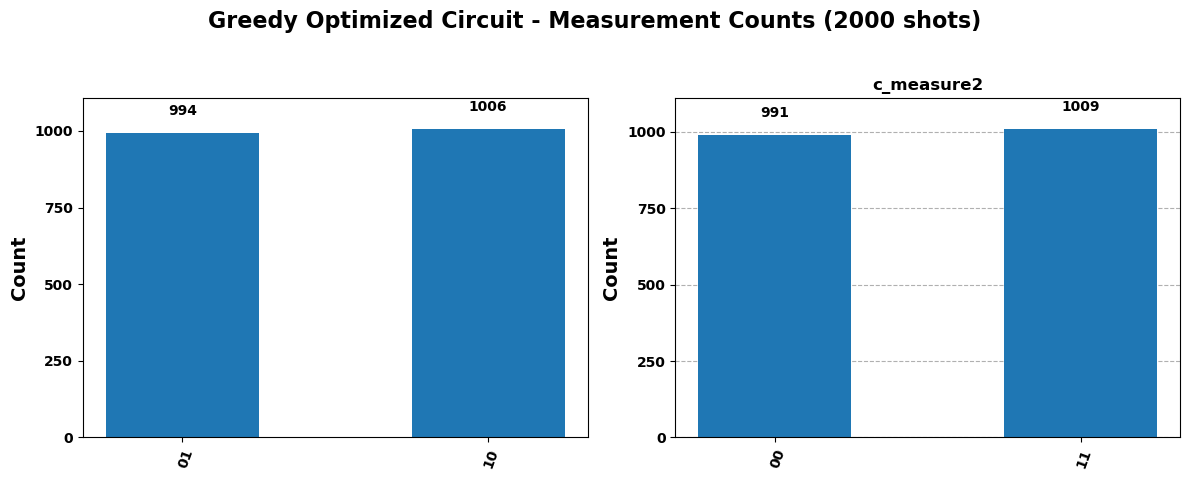

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


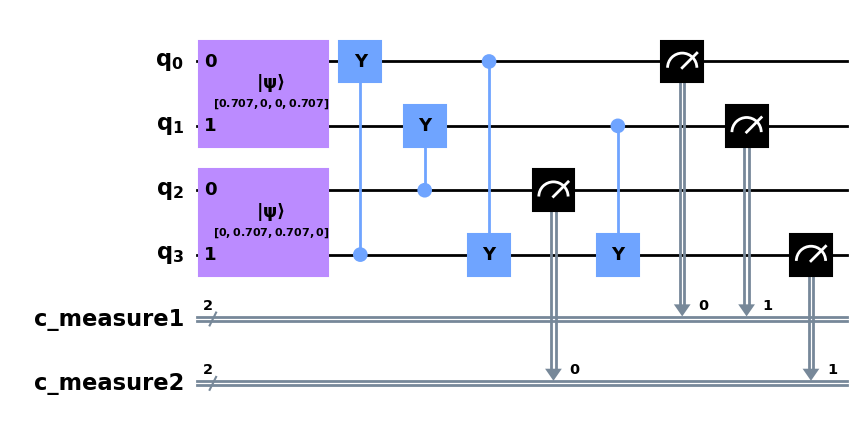

In [ ]:
plot_measurement_histograms(final_best_circuit_brute_force, nshots=2000, title_prefix="Greedy Optimized Circuit")
final_best_circuit_brute_force.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

In [6]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 20
min_greedy_depth = 10

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ_bell,
    circ_ghz_ish,
    state_probs_bell,
    state_probs_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=5000,
    threshold=0.05
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 8
Number of refined CNOT candidates: 12

--- Starting Epoch 1/12 (Addition) with CNOT: (3, 2) (KL: 30.161433) ---
    --> Found a better KL on this path: 10.007299 at depth 2
    --> Found a better KL on this path: 9.213911 at depth 3
    --> Found a better KL on this path: 9.145891 at depth 5
  Epoch 1 best KL Sum: 9.145891
  --> Epoch 1 found a new overall best KL Sum: 9.145891

--- Starting Epoch 2/12 (Addition) with CNOT: (1, 0) (KL: 30.125340) ---
    --> Found a better KL on this path: 19.409307 at depth 2
    --> Found a better KL on this path: 18.832821 at depth 3
    --> Found a better KL on this path: 9.062203 at depth 4
    --> Found a better KL on this path: 0.000015 at depth 6
  KL Sum (0.000015) below tolerance. Early stopping this epoch.
  Epoch 2 best KL Sum: 0.000015
  --> Epoch 2 found a new overall best KL Sum: 0.000015

--- Starting Epoch 3/12


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'10': 1009, '01': 991}
Counts for c_measure2: {'11': 1006, '00': 994}


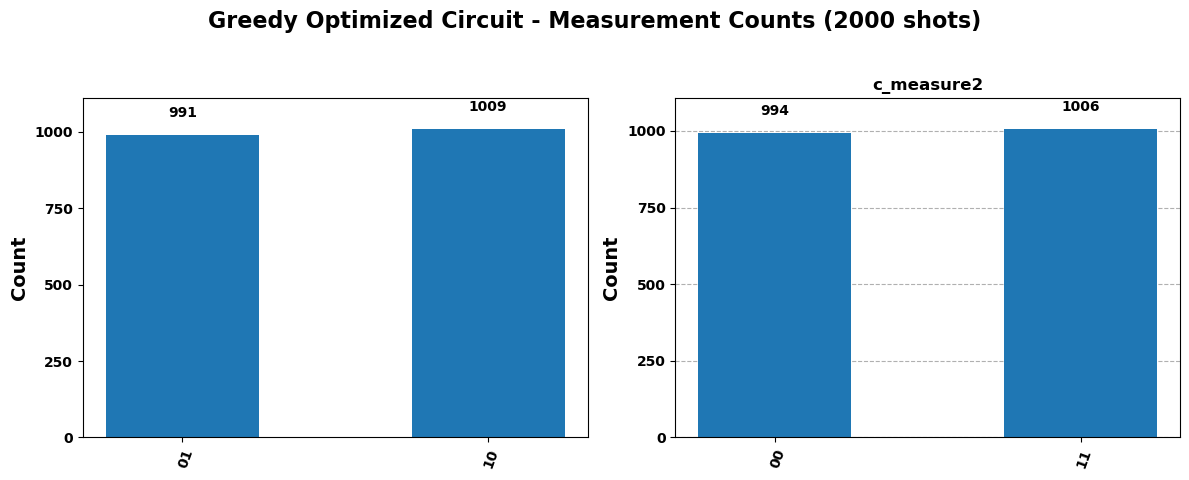

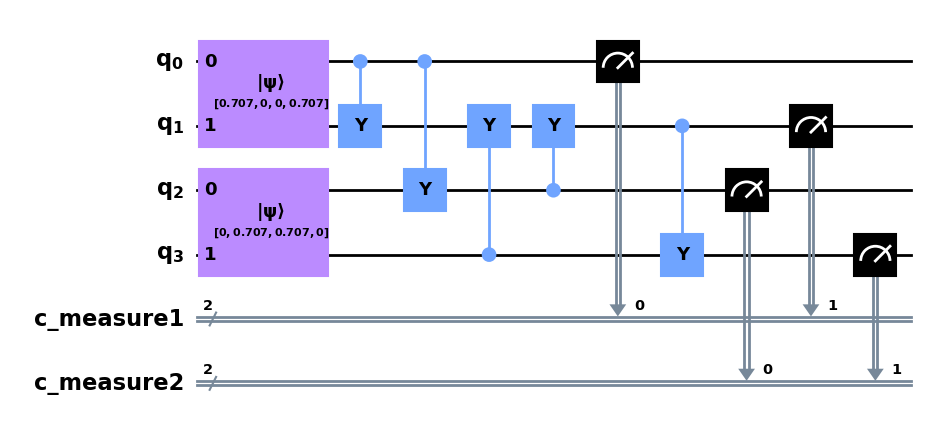

In [7]:
plot_measurement_histograms(final_best_circuit_search, nshots=2000, title_prefix="Greedy Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)


--- Running CRX Angle Optimization (based on Multi-epoch CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  Optimized Angles: ['3.1416', '3.1416', '3.1416', '3.1416']
CRX Angle Optimization took: 10.30 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['3.1416', '3.1416', '3.1416', '3.1416']
  Minimum Combined KL Divergence with Optimized CRX: 0.000499


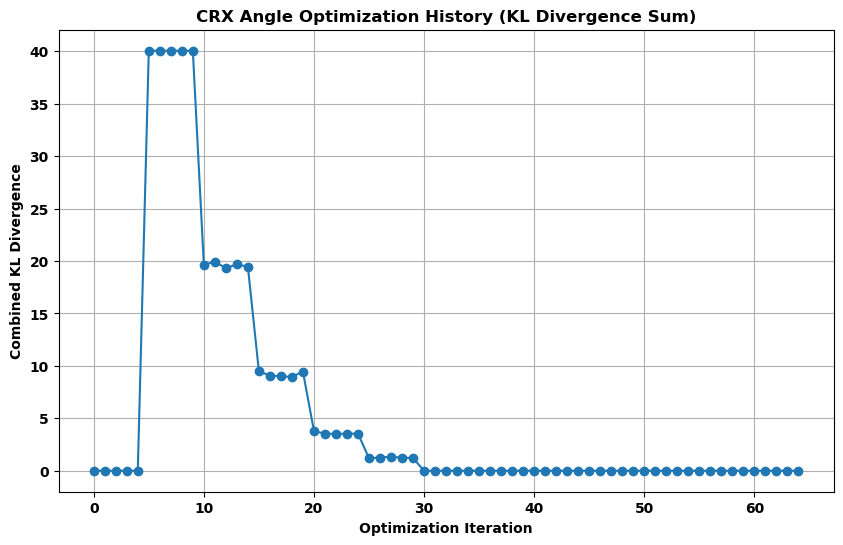


--- Final Optimized Circuit (CRX Angles) ---
              ┌──────────────────────────────────┐┌────────────┐              »
         q_0: ┤0                                 ├┤ Rx(3.1416) ├──────────────»
              │  Initialize(0.70711,0,0,0.70711) │└─────┬──────┘┌────────────┐»
         q_1: ┤1                                 ├──────┼───────┤ Rx(3.1416) ├»
              ├──────────────────────────────────┤      │       └─────┬──────┘»
         q_2: ┤0                                 ├──────┼─────────────■───────»
              │  Initialize(0,0.70711,0.70711,0) │      │                     »
         q_3: ┤1                                 ├──────■─────────────────────»
              └──────────────────────────────────┘                            »
c_measure1: 2/════════════════════════════════════════════════════════════════»
                                                                              »
c_measure2: 2/════════════════════════════════════════════════════════════

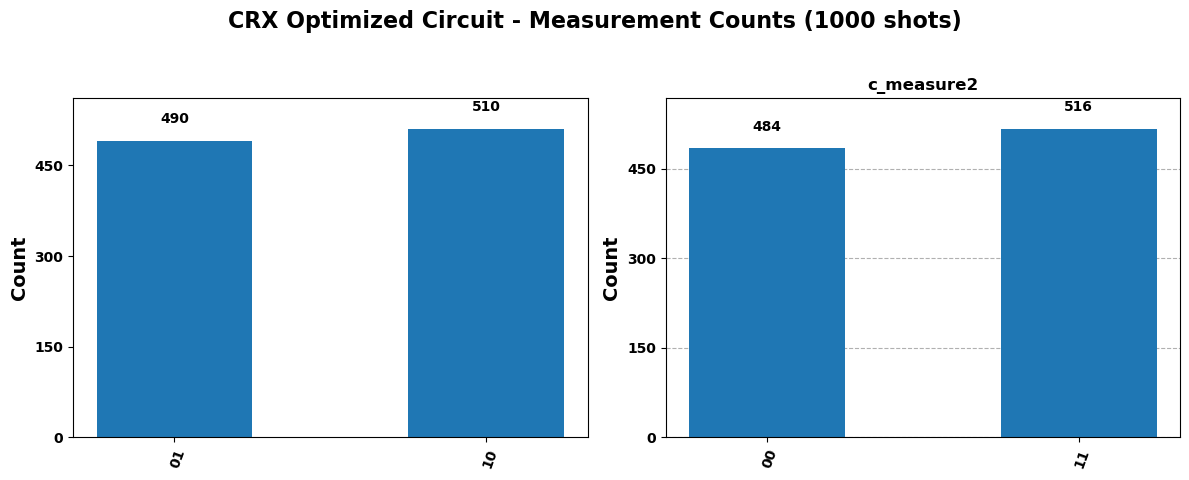

({'01': 490, '10': 510}, {'00': 484, '11': 516})

In [8]:
import matplotlib.pyplot as plt

# --- Optimize CRX angles for the Brute-Force CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on Multi-epoch CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ_bell,
    circ_ghz_ish,
    state_probs_target1_amplitudes,
    state_probs_target2_amplitudes,
    best_cnot_sequence_brute_force, # Use the CNOT topology found by brute-force
    nshots=2000,
    etol=1e-4,
    opt_method='L-BFGS-B', # Using L-BFGS-B for angle optimization
    initial_angle_value=np.pi # Start angles at pi (CNOT equivalent)
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish),
    circ_bell.num_qubits,
    best_cnot_sequence_brute_force,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [9]:
# This is a good set of functions!
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix

# This is the call:
# --- Demonstrate Iterative Pairwise Search ---
print("\n" + "="*40)
print("--- Running iterative pair-wise Search ---")
print("="*40)

# Apply vector normalization to the new dictionaries
normalized_state_target1_amplitudes = vector_normalize_dictionary_values(state_probs_target1_amplitudes)
normalized_state_target2_amplitudes = vector_normalize_dictionary_values(state_probs_target2_amplitudes)
normalized_state_bell = vector_normalize_dictionary_values(state_probs_bell)
normalized_state_ghz_ish = vector_normalize_dictionary_values(state_probs_ghz_ish)


initial_cnot_config, best_add_sequence, best_add_kl_sum = find_best_cnot_sequence_iterative_n_wise(
    circ_bell,
    circ_ghz_ish,
    normalized_state_bell, 
    normalized_state_ghz_ish,
    normalized_state_target1_amplitudes,
    normalized_state_target2_amplitudes,
    nshots=5000,
    threshold=0.01,
    nchoose=3
)

print("\n" + "="*40)
if best_add_sequence: # Use best_add_sequence as it's the result of the addition phase
    print("Iterative Search Optimal CNOT sequence found after addition phase:")
    for cnot in best_add_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {best_add_kl_sum:.6f}")

    # Construct and draw the final best circuit from the search
    ng_circ1_for_search = circ_bell.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_add_sequence
    )
    print("\n--- Final Optimized Circuit (Iterative Pairwise Search) ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Iterative Pairwise Search: No CNOT configuration sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {best_add_kl_sum:.6f}")
    # Draw the baseline circuit
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ_bell, circ_ghz_ish)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ_bell.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")



--- Running iterative pair-wise Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 12
Initial KL-divergence: 40.060262
  - Starting CNOT search -
  - No. tested pairs: 1320 | Best pair KL sum: 8.922284
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 8.922284
  - No. tested pairs: 504 | Best pair KL sum: 0.000009
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.000009
  - No. tested pairs: 120 | Best pair KL sum: 8.970206
  - Best single CNOT insertion KL Sum: 0.000052
  - No significant improvement found from pairs or single CNOTs. Ending search.

--- Pairwise Addition Result ---
Best sequence after addition: [(2, 1), (0, 2), (3, 0), (0, 3), (3, 2), (1, 2)]
KL sum after addition: 0.000009

Total search time: 352.20 seconds.

Iterative Search Optimal CNOT sequence found after addition phase:
  q[2] -> q[1]
  q[0] -> q[2]
  q[3] -> q[0]
  q[0] -


--- Simulating and Plotting Histograms for: Greedy Optimized Circuit ---
Counts for c_measure1: {'01': 1021, '10': 979}
Counts for c_measure2: {'00': 1004, '11': 996}


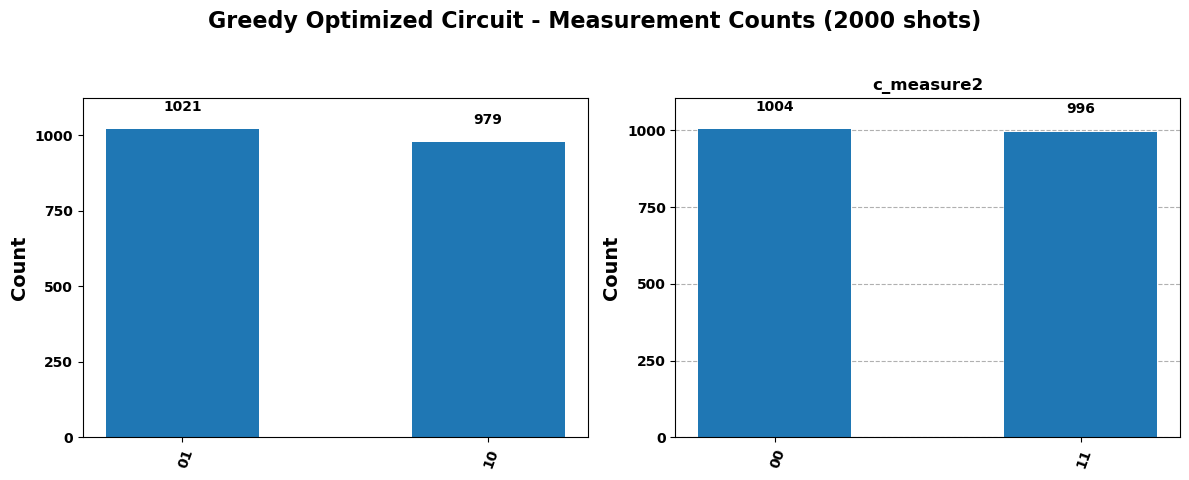

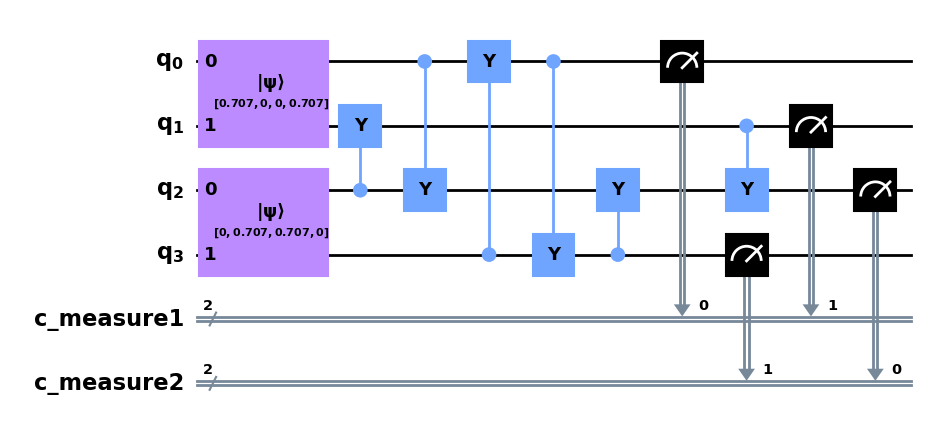

In [10]:
plot_measurement_histograms(final_best_circuit_search, nshots=2000, title_prefix="Greedy Optimized Circuit")
final_best_circuit_search.draw(output="mpl", style="clifford", fold=40,  scale = 1.0)

In [11]:
# --- New Dictionary Definitions ---
# State Set 5a: A simple distribution where states with more '1's have higher values.
state_set_5a_dict = {
    '000': 1,
    '001': 2,
    '010': 2,
    '100': 2,
    '011': 4,
    '101': 4,
    '110': 4,
    '111': 8
}

# State Set 6a: A bell state-like distribution where certain states are highly probable.
# This simulates an entangled state before interaction.
state_set_6a_dict = {
    '0000': 5,
    '0001': 1,
    '0010': 1,
    '0011': 1,
    '0100': 1,
    '0101': 1,
    '0110': 1,
    '0111': 1,
    '1000': 1,
    '1001': 1,
    '1010': 1,
    '1011': 1,
    '1100': 1,
    '1101': 1,
    '1110': 1,
    '1111': 5
}

# Interacted State Set 5a: Simulating a CNOT interaction between qubits 1 and 2
# We increase the probability of entangled states like '011' and '110'.
interacted_state_set_5a_dict = {
    '000': 1,
    '001': 1,
    '010': 1,
    '100': 1,
    '011': 6,
    '101': 2,
    '110': 6,
    '111': 2
}

# Interacted State Set 6a: The bell state distribution is now more focused on states
# that would result from an interaction, such as '0000' and '1111' becoming highly probable.
interacted_state_set_6a_dict = {
    '0000': 8,
    '0001': 1,
    '0010': 1,
    '0011': 1,
    '0100': 1,
    '0101': 1,
    '0110': 1,
    '0111': 1,
    '1000': 1,
    '1001': 1,
    '1010': 1,
    '1011': 1,
    '1100': 1,
    '1101': 1,
    '1110': 1,
    '1111': 8
}

# --- Apply and Print ---
print("--- New Dictionary Definitions ---")
print("State Set 5a:", state_set_5a_dict)
print("State Set 6a:", state_set_6a_dict)
print("Interacted State Set 5a:", interacted_state_set_5a_dict)
print("Interacted State Set 6a:", interacted_state_set_6a_dict)

# Apply vector normalization to the new dictionaries
normalized_state_set_5a_dict_vec = vector_normalize_dictionary_values(state_set_5a_dict)
normalized_state_set_6a_dict_vec = vector_normalize_dictionary_values(state_set_6a_dict)
normalized_interacted_state_set_5a_dict_vec = vector_normalize_dictionary_values(interacted_state_set_5a_dict)
normalized_interacted_state_set_6a_dict_vec = vector_normalize_dictionary_values(interacted_state_set_6a_dict)

print("\n--- Vector Normalized Dictionary Definitions ---")
print("Normalized State Set 5a (Vector Norm):", normalized_state_set_5a_dict_vec)
print("Normalized State Set 6a (Vector Norm):", normalized_state_set_6a_dict_vec)
print("Normalized Interacted State Set 5a (Vector Norm):", normalized_interacted_state_set_5a_dict_vec)
print("Normalized Interacted State Set 6a (Vector Norm):", normalized_interacted_state_set_6a_dict_vec)
# 1. Define initial circuits for concatenation
circ1 = create_initial_circuit2(normalized_state_set_5a_dict_vec)
circ2 = create_initial_circuit2(normalized_state_set_6a_dict_vec)

--- New Dictionary Definitions ---
State Set 5a: {'000': 1, '001': 2, '010': 2, '100': 2, '011': 4, '101': 4, '110': 4, '111': 8}
State Set 6a: {'0000': 5, '0001': 1, '0010': 1, '0011': 1, '0100': 1, '0101': 1, '0110': 1, '0111': 1, '1000': 1, '1001': 1, '1010': 1, '1011': 1, '1100': 1, '1101': 1, '1110': 1, '1111': 5}
Interacted State Set 5a: {'000': 1, '001': 1, '010': 1, '100': 1, '011': 6, '101': 2, '110': 6, '111': 2}
Interacted State Set 6a: {'0000': 8, '0001': 1, '0010': 1, '0011': 1, '0100': 1, '0101': 1, '0110': 1, '0111': 1, '1000': 1, '1001': 1, '1010': 1, '1011': 1, '1100': 1, '1101': 1, '1110': 1, '1111': 8}

--- Vector Normalized Dictionary Definitions ---
Normalized State Set 5a (Vector Norm): {'000': 0.08944271909999159, '001': 0.17888543819998318, '010': 0.17888543819998318, '100': 0.17888543819998318, '011': 0.35777087639996635, '101': 0.35777087639996635, '110': 0.35777087639996635, '111': 0.7155417527999327}
Normalized State Set 6a (Vector Norm): {'0000': 0.625, '00

In [12]:
print("\n" + "="*40)
print("--- Running N-wise iterative Refined Search ---")
print("="*40)

initial_cnot_config, best_cnot_sequence, min_kl_sum  = find_best_cnot_sequence_iterative_n_wise(
    circ1,
    circ2,
    normalized_state_set_5a_dict_vec,
    normalized_state_set_6a_dict_vec,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    nshots=5000,
    threshold=0.01,
    nchoose=2
)

print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )
    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running N-wise iterative Refined Search ---

--- Starting Iterative Pairwise Search ---
Number of initial CNOT candidates: 42
Initial KL-divergence: 1.203130
  - Starting CNOT search -
  - No. tested pairs: 1722 | Best pair KL sum: 0.337113
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.337113
  - No. tested pairs: 1560 | Best pair KL sum: 0.335339
  - Single CNOT insertion did not improve upon the best pair.
  - Adopted new sequence. New KL Sum: 0.335339
  - No. tested pairs: 1406 | Best pair KL sum: 0.339789
  - Single CNOT insertion did not improve upon the best pair.
  - No significant improvement found from pairs or single CNOTs. Ending search.

--- Pairwise Addition Result ---
Best sequence after addition: [(6, 2), (2, 0), (6, 5), (4, 5)]
KL sum after addition: 0.335339

Total search time: 984.13 seconds.

Multi-Epoch Search Optimal CNOT sequence found:
  q[6] -> q[2]
  q[2] -> q[0]
  q[6] -> q[5]
  q[4] -> q[5]
With min


--- Running CRX Angle Optimization (based on CNOT topology) ---

--- Starting CRX Angle Optimization (4 CRX gates) ---

Optimization Results:
  Success: True
  Message: Optimization terminated successfully.
  Optimized Angles: ['2.8029', '3.1416', '3.1416', '3.1416']
CRX Angle Optimization took: 15.10 seconds

CRX Angle Optimization Results:
  Optimized Angles: ['2.8029', '3.1416', '3.1416', '3.1416']
  Minimum Combined KL Divergence with Optimized CRX: 0.364479


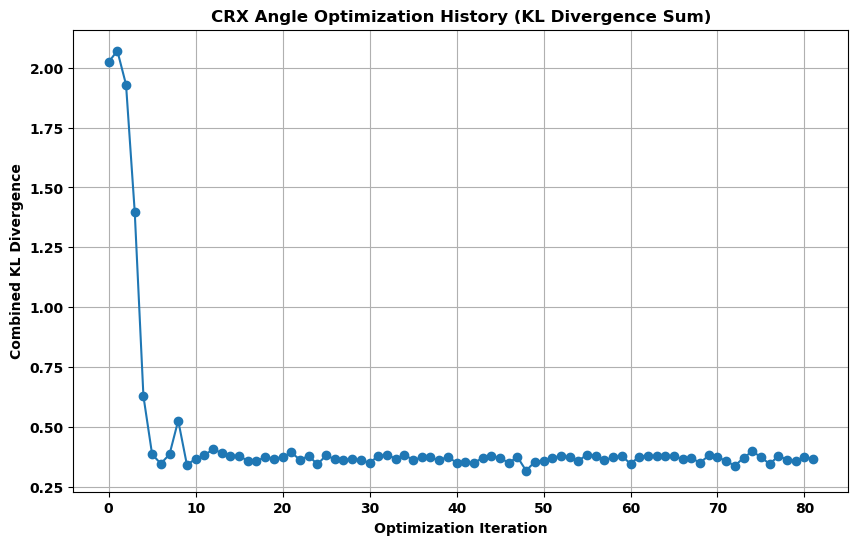


--- Final Optimized Circuit (CRX Angles) ---
              »
         q_0: »
              »
         q_1: »
              »
         q_2: »
              »
         q_3: »
              »
         q_4: »
              »
         q_5: »
              »
         q_6: »
              »
c_measure1: 3/»
              »
c_measure2: 4/»
              »
«                             ┌───────────────────────────────────────────────────────────────────────────────┐                »
«         q_0: ───────────────┤0                                                                              ├────────────────»
«                             │                                                                               │                »
«         q_1: ───────────────┤1 Initialize(0.089443,0.17889,0.17889,0.35777,0.17889,0.35777,0.35777,0.71554) ├────────────────»
«                             │                                                                               │                »
«    

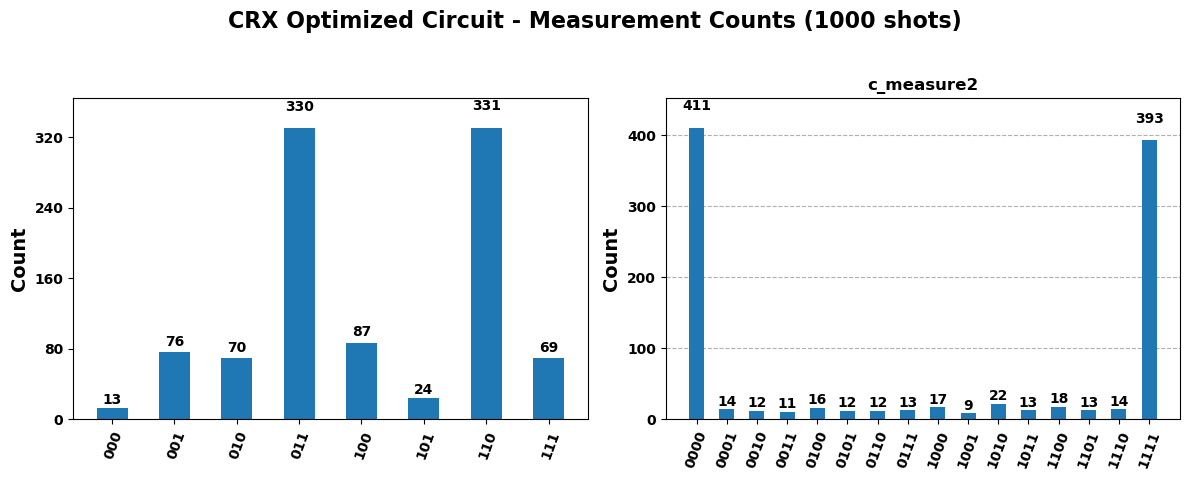

({'011': 330,
  '110': 331,
  '010': 70,
  '111': 69,
  '100': 87,
  '001': 76,
  '101': 24,
  '000': 13},
 {'1111': 393,
  '0000': 411,
  '1010': 22,
  '1110': 14,
  '0111': 13,
  '1101': 13,
  '1000': 17,
  '0010': 12,
  '1001': 9,
  '0100': 16,
  '0101': 12,
  '0001': 14,
  '1100': 18,
  '0110': 12,
  '1011': 13,
  '0011': 11})

In [13]:
# --- Optimize CRX angles for the pair-wise CNOT topology ---
print("\n" + "="*40)
print("--- Running CRX Angle Optimization (based on CNOT topology) ---")
print("="*40)
optimized_crx_angles, min_kl_crx_optimized, crx_optimization_history = optimize_crx_angles(
    circ1,
    circ2,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    best_cnot_sequence, # Use the CNOT topology found by pair-wise
    nshots=5000,
    opt_method='COBYLA', # Using L-BFGS-B COBYLA for angle optimization
    initial_angle_value= np.pi/2 # Start angles at pi (CNOT equivalent) | pi/2 mixed
)

print("\n" + "="*40)
print(f"CRX Angle Optimization Results:")
print(f"  Optimized Angles: {[f'{angle:.4f}' for angle in optimized_crx_angles]}")
print(f"  Minimum Combined KL Divergence with Optimized CRX: {min_kl_crx_optimized:.6f}")
#print(f"  Optimization History (KL Sums per iteration): {[f'{val:.6f}' for val in crx_optimization_history]}")

# Plot the optimization history
if crx_optimization_history:
    plt.figure(figsize=(10, 6))
    plt.plot(crx_optimization_history, marker='o', linestyle='-')
    plt.title('CRX Angle Optimization History (KL Divergence Sum)')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Combined KL Divergence')
    plt.grid(True)
    #plt.xticks(range(len(crx_optimization_history))) # Ensure all iterations are shown on x-axis
    plt.show()
    plt.close() # Close the figure to free memory


# Construct and draw the final circuit with optimized CRX angles
final_crx_optimized_circuit = add_crx_gates_and_measurements_to_circuit(
    concatenate_circuits_with_separate_measurements(circ1, circ2),
    circ1.num_qubits,
    best_cnot_sequence,
    optimized_crx_angles
)
print("\n--- Final Optimized Circuit (CRX Angles) ---")
print(final_crx_optimized_circuit.draw('text'))

# Plot histograms for the CRX optimized circuit
plot_measurement_histograms(final_crx_optimized_circuit, nshots=1000, title_prefix="CRX Optimized Circuit")

In [ ]:
print("\n" + "="*40)
print("--- Running Multi-Epoch Refined Search ---")
print("="*40)

n_epochs = 50
min_greedy_depth = 40

best_cnot_sequence, min_kl_sum = find_best_cnot_sequence_multi_epoch(
    circ1,
    circ2,
    normalized_state_set_5a_dict_vec,
    normalized_state_set_6a_dict_vec,
    normalized_interacted_state_set_5a_dict_vec,
    normalized_interacted_state_set_6a_dict_vec,
    n_epochs=n_epochs,
    min_cnot_depth=min_greedy_depth,
    nshots=1000,
    threshold=0.05
)


print("\n" + "="*40)
if best_cnot_sequence:
    print(f"Multi-Epoch Search Optimal CNOT sequence found:")
    for cnot in best_cnot_sequence:
        print(f"  q[{cnot[0]}] -> q[{cnot[1]}]")
    print(f"With minimum combined KL Divergence: {min_kl_sum:.6f}")

    ng_circ1_for_search = circ1.num_qubits
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, ng_circ1_for_search, best_cnot_sequence
    )


    print("\n--- Final Optimized Circuit ---")
    print(final_best_circuit_search.draw('text'))
else:
    print("Multi-Epoch Search: No sequence improved the KL divergence beyond the baseline.")
    print(f"Baseline KL Divergence: {min_kl_sum:.6f}")
    base_combined_circuit_search = concatenate_circuits_with_separate_measurements(circ1, circ2)
    final_best_circuit_search = add_cnots_and_measurements_to_circuit(
        base_combined_circuit_search, circ1.num_qubits, []
    )
    print("\n--- Baseline Circuit (No CNOTs) ---")
    print(final_best_circuit_search.draw('text'))
print("="*40 + "\n")


--- Running Multi-Epoch Refined Search ---

--- Starting Multi-Epoch Refined Search ---
Number of original CNOT candidates: 24
Number of refined CNOT candidates: 42

--- Starting Epoch 1/42 (Addition) with CNOT: (0, 3) (KL: 3.394531) ---

--- Starting Epoch 2/42 (Addition) with CNOT: (1, 0) (KL: 0.706516) ---
    --> Found a better KL on this path: 0.603537 at depth 2
    --> Found a better KL on this path: 0.548541 at depth 3
    --> Found a better KL on this path: 0.374047 at depth 5
  Epoch 2 best KL Sum: 0.374047
  --> Epoch 2 found a new overall best KL Sum: 0.374047

--- Starting Epoch 3/42 (Addition) with CNOT: (4, 1) (KL: 1.389947) ---

--- Starting Epoch 4/42 (Addition) with CNOT: (6, 1) (KL: 1.317467) ---

--- Starting Epoch 5/42 (Addition) with CNOT: (3, 5) (KL: 2.741150) ---

--- Starting Epoch 6/42 (Addition) with CNOT: (1, 6) (KL: 3.589476) ---

--- Starting Epoch 7/42 (Addition) with CNOT: (3, 0) (KL: 0.769689) ---
    --> Found a better KL on this path: 0.368231 at dep